# Basal vs Hillock 

In [1]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'refined-manual-niches'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %% Load the object
comb = sc.read_h5ad(COMB_PATH)

In [3]:
comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_

In [4]:
import decoupler as dc
import pandas as pd
import numpy as np

CELLTYPE_COL = "ann_lvl_3_refined"
DONOR_COL = "donor"
CONDITION_COL = "condition"

# --------------------------------------------------
# 1. Subset to CF basal + Hillock cells
# --------------------------------------------------

bh = comb[
    (comb.obs[CONDITION_COL] == "CF") &
    (comb.obs[CELLTYPE_COL].isin(["BC", "Hillock"]))
].copy()

bh

AnnData object with n_obs × n_vars = 55672 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_6'

In [5]:
bh

AnnData object with n_obs × n_vars = 55672 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_6'

In [6]:
# inspect number of cells
pd.crosstab(
    bh.obs[DONOR_COL],
    bh.obs[CELLTYPE_COL]
)

ann_lvl_3_refined,BC,Hillock
donor,,
PWCF01,8658,86
PWCF02,16065,124
PWCF03,15222,40
PWCF05,13950,1527


In [12]:
# --------------------------------------------------
# 2. Donor × cell-type pseudobulk
# --------------------------------------------------

pdata = dc.pp.pseudobulk(
    bh,
    sample_col=DONOR_COL,
    groups_col=CELLTYPE_COL,
    layer="counts",
    mode="sum",
)

pdata

AnnData object with n_obs × n_vars = 8 × 2000
    obs: 'donor', 'ann_lvl_3_refined', 'scale', 'slide_ID', 'slide_name', 'condition', 'run', 'modulator', 'age', 'mutation', 'sex', '_scvi_batch', '_scvi_labels', 'airway-epithelium_leiden_n10_0.4', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    layers: 'psbulk_props'

In [13]:
pdata.obs[
    [
        DONOR_COL,
        CELLTYPE_COL,
        "psbulk_cells",
        "psbulk_counts",
    ]
]

,donor,ann_lvl_3_refined,psbulk_cells,psbulk_counts
PWCF01_BC,PWCF01,BC,8658.0,2398569.0
PWCF02_BC,PWCF02,BC,16065.0,856267.0
PWCF03_BC,PWCF03,BC,15222.0,1147662.0
PWCF05_BC,PWCF05,BC,13950.0,1355373.0
PWCF01_Hillock,PWCF01,Hillock,86.0,46757.0
PWCF02_Hillock,PWCF02,Hillock,124.0,9743.0
PWCF03_Hillock,PWCF03,Hillock,40.0,7956.0
PWCF05_Hillock,PWCF05,Hillock,1527.0,290647.0


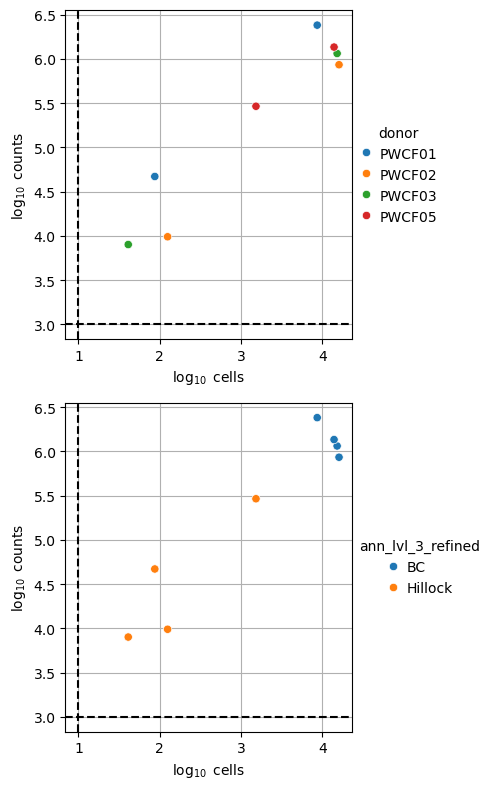

In [15]:
dc.pl.filter_samples(
    adata=pdata,
    groupby=["donor", "ann_lvl_3_refined"],
    min_cells=10,
    min_counts=1000,
    figsize=(5, 8),
)

In [16]:
dc.pp.filter_samples(pdata, min_cells=10, min_counts=1000)

In [21]:
# Store raw counts in layers
pdata.layers["counts"] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata, key="counts", inplace=True)

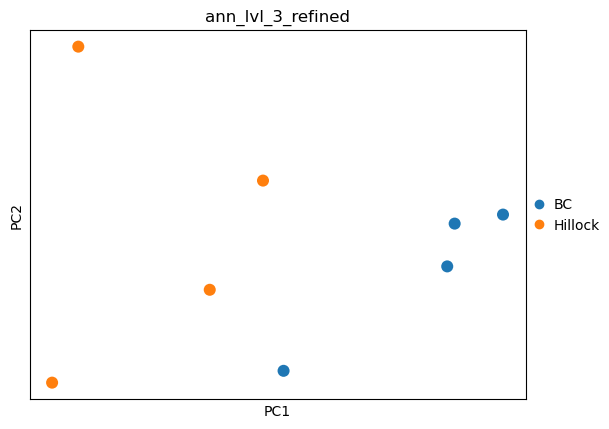

In [24]:
sc.pl.pca(
    pdata,
    color=['ann_lvl_3_refined'],
    ncols=1,
    size=300,
    frameon=True,
)

In [25]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=pdata,
    design="~run + ann_lvl_3_refined",
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["ann_lvl_3_refined", "Hillock", "BC"], inference=inference)

# Compute Wald test
stat_res.summary()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.33 seconds.

Fitting dispersion trend curve...
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.31 seconds.

Fitting LFCs...
... done in 0.28 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.16 seconds.



Log2 fold change & Wald test p-value: ann_lvl_3_refined Hillock vs BC
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M     19.063548       -0.400273  0.515532 -0.776427  0.437497       NaN
AASS    74.934506       -1.333056  0.446092 -2.988301  0.002805  0.019234
AATK    25.354284       -0.144406  0.473324 -0.305090  0.760298       NaN
ABCA5   60.061559       -1.443630  0.522064 -2.765238  0.005688  0.031887
ABCC9   36.347140       -1.762031  0.569761 -3.092581  0.001984       NaN
...           ...             ...       ...       ...       ...       ...
ZG16B   69.754223        0.050602  0.339272  0.149149  0.881436  0.953472
ZNF521  22.714256        0.155438  0.422627  0.367789  0.713030       NaN
ZNF536  24.687989        0.327771  0.445467  0.735792  0.461858       NaN
ZNF622  65.172820        0.246470  0.381615  0.645860  0.518370  0.702712
ZP3     35.300581       -0.348265  0.431259 -0.807554  0.419347       NaN

[2000 rows x 6 columns]


In [26]:
# Extract results
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A2M,19.063548,-0.400273,0.515532,-0.776427,0.437497,NaN
AASS,74.934506,-1.333056,0.446092,-2.988301,0.002805,0.019234
AATK,25.354284,-0.144406,0.473324,-0.305090,0.760298,NaN
ABCA5,60.061559,-1.443630,0.522064,-2.765238,0.005688,0.031887
ABCC9,36.347140,-1.762031,0.569761,-3.092581,0.001984,NaN
...,...,...,...,...,...,...
ZG16B,69.754223,0.050602,0.339272,0.149149,0.881436,0.953472
ZNF521,22.714256,0.155438,0.422627,0.367789,0.713030,NaN
ZNF536,24.687989,0.327771,0.445467,0.735792,0.461858,NaN
ZNF622,65.172820,0.246470,0.381615,0.645860,0.518370,0.702712


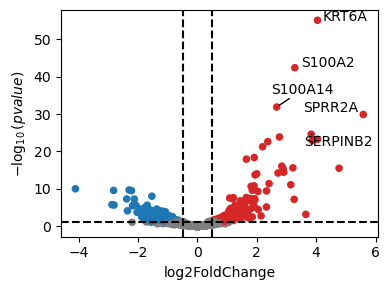

In [27]:
dc.pl.volcano(results_df, x="log2FoldChange", y="pvalue")

In [28]:
data = results_df[["stat"]].T.rename(index={"stat": "disease.vs.normal"})
data

,A2M,AASS,AATK,ABCA5,ABCC9,ABCG1,ABHD3,ABI3BP,ACE,ACE2,...,YWHAH,ZBTB16,ZDHHC8,ZFHX4,ZFPM2,ZG16B,ZNF521,ZNF536,ZNF622,ZP3
disease.vs.normal,-0.776427,-2.988301,-0.30509,-2.765238,-3.092581,-1.490793,-0.009188,0.050102,0.264571,0.8583,...,1.42782,-2.322534,-0.124204,-0.656723,0.016171,0.149149,0.367789,0.735792,0.64586,-0.807554


## CollecTRI

In [29]:
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


In [30]:
# Run
tf_acts, tf_padj = dc.mt.ulm(data=data, net=collectri)

# Filter by sign padj
msk = (tf_padj.T < 0.05).iloc[:, 0]
tf_acts = tf_acts.loc[:, msk]

tf_acts

,HOXB2,MBD2,NFE2L2,RFXANK,RFXAP,SP1,TFAP4
disease.vs.normal,4.803635,3.677307,3.858297,-3.642188,-3.969903,3.44752,3.481841


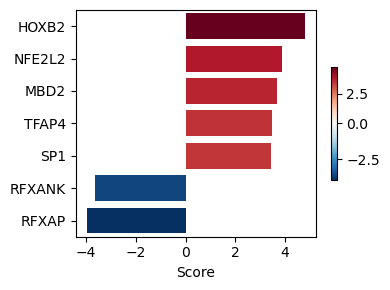

In [31]:
dc.pl.barplot(data=tf_acts, name="disease.vs.normal", figsize=(4, 3))

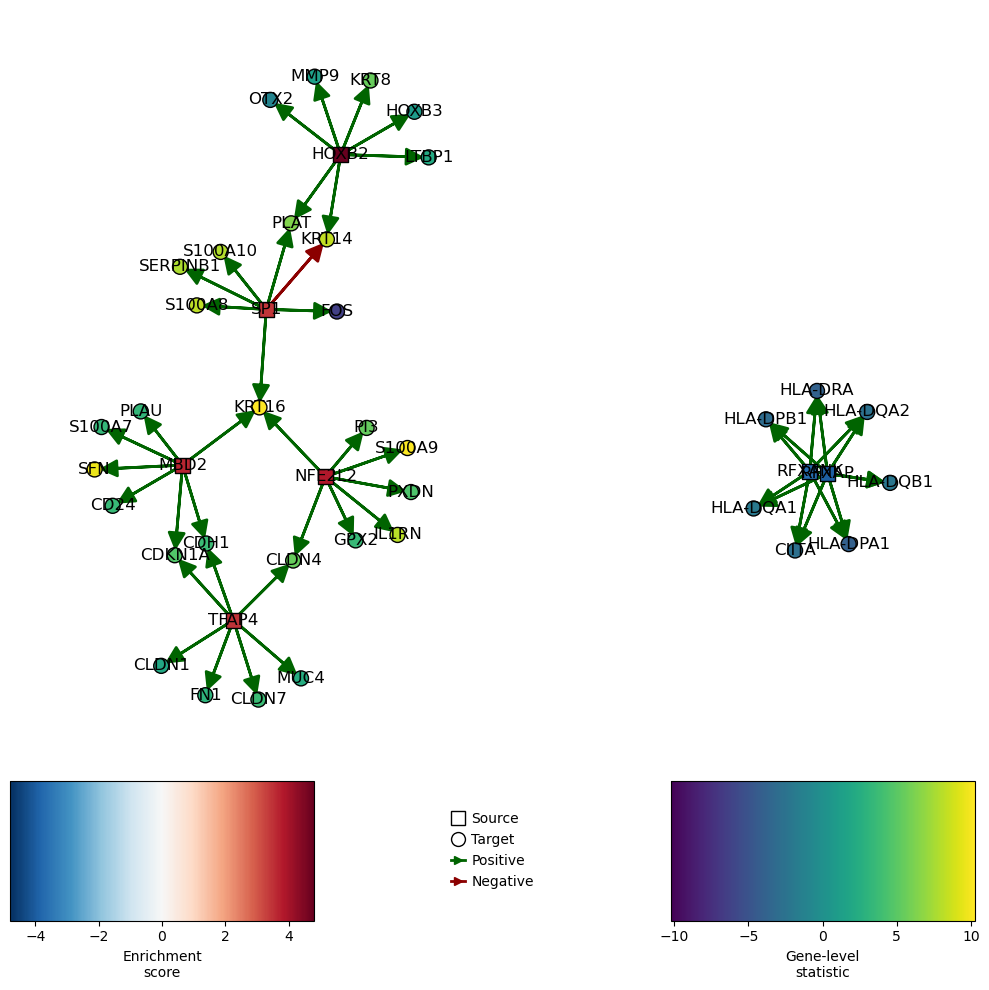

In [65]:
tf_list = tf_acts.columns.tolist()

dc.pl.network(
    net=collectri,
    data=data,
    score=tf_acts,
    sources=tf_list,
    targets=7,
    figsize=(10, 10),
    vcenter=True,
    by_abs=True,
    size_node=15,
    size_label=1,
    t_label="Gene-level\nstatistic",
)

In [63]:
dc.pl.network?

Signature:
dc.pl.network(
    net,
    data: pandas.core.frame.DataFrame = None,
    score: pandas.core.frame.DataFrame = None,
    sources: int | list | str = 5,
    targets: int | list | str = 10,
    by_abs: bool = True,
    size_node: int = 5,
    size_label: float | int = 2.5,
    s_cmap: str = 'RdBu_r',
    t_cmap: str = 'viridis',
    vcenter: bool = False,
    c_pos_w: str = 'darkgreen',
    c_neg_w: str = 'darkred',
    s_label: str = 'Enrichment\nscore',
    t_label: str = 'Gene\nexpression',
    layout: str = 'kk',
    kw_igraph: dict | None = None,
    **kwargs,
)
Docstring:
Plot results of enrichment analysis as network.

Parameters
----------
net
    Dataframe in long format. Must include ``source`` and ``target`` columns, and optionally a ``weight`` column.
data
    Input of enrichment analysis, needs to be a one row dataframe with targets as features. Used to filter net.
score
    Ouput of enrichment analysis, needs to be a one row dataframe with sources as features. Us

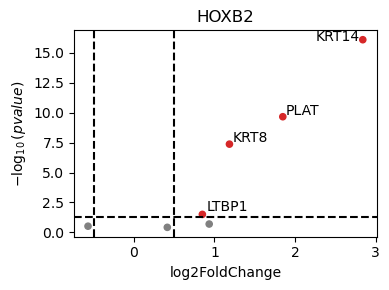

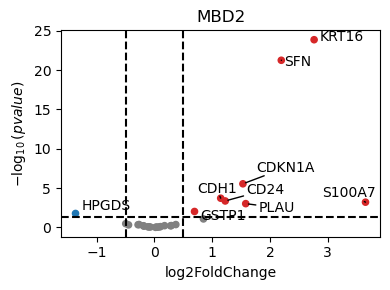

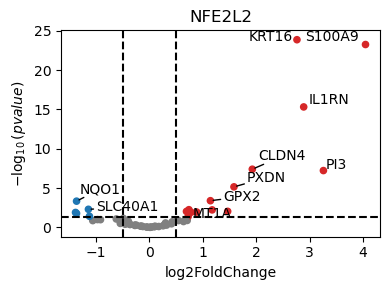

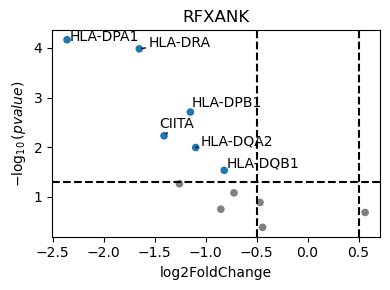

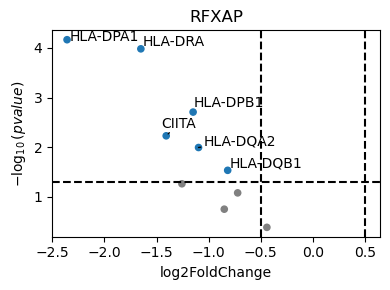

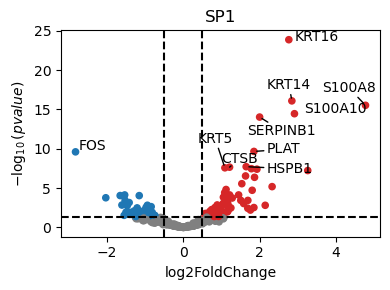

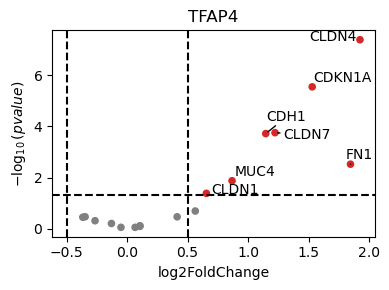

In [41]:
for tf in tf_list:
    dc.pl.volcano(
        data=results_df,
        x="log2FoldChange",
        y="pvalue",
        net=collectri,
        name=tf,
        top=10,
    )

## PROGENy

In [44]:
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


In [45]:
# Run
pw_acts, pw_padj = dc.mt.ulm(data=data, net=progeny)

# Filter by sign padj
msk = (pw_padj.T < 0.05).iloc[:, 0]
pw_acts = pw_acts.loc[:, msk]

pw_acts

,EGFR,MAPK,NFkB,PI3K,TNFa,VEGF
disease.vs.normal,8.608501,5.728927,5.154305,4.020876,5.780086,7.013966


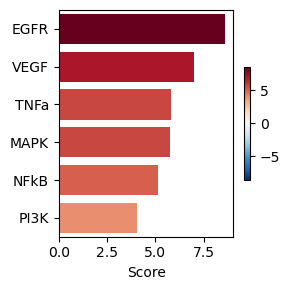

In [46]:
dc.pl.barplot(data=pw_acts, name="disease.vs.normal", figsize=(3, 3))

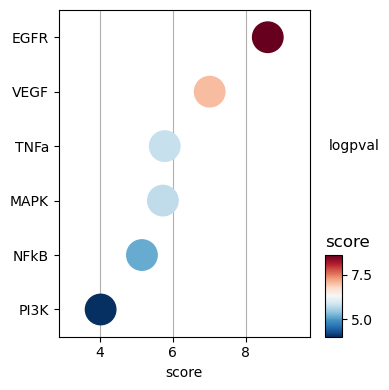

In [47]:
# Transform to df
df = pw_acts.melt(value_name="score").merge(
    pw_padj.melt(value_name="pvalue")
    .assign(logpval=lambda x: x["pvalue"].clip(2.22e-4, 1))
    .assign(logpval=lambda x: -np.log10(x["logpval"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="logpval", c="score", scale=1, figsize=(4, 4))

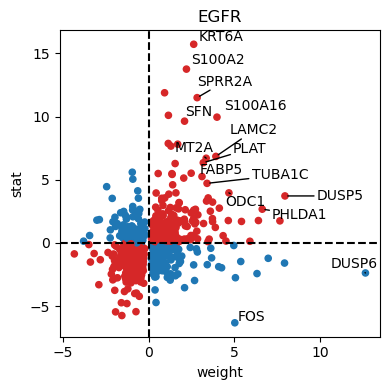

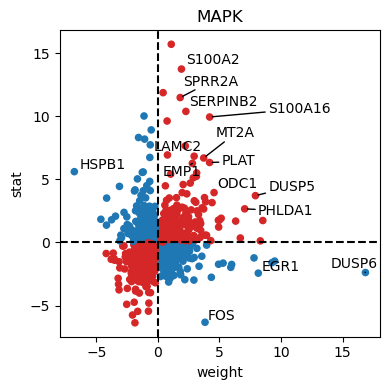

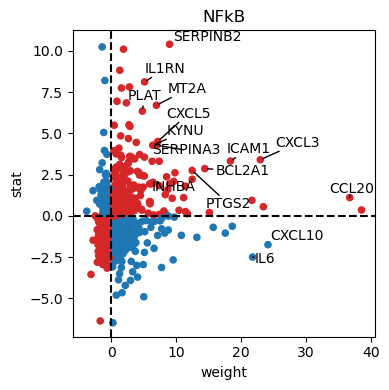

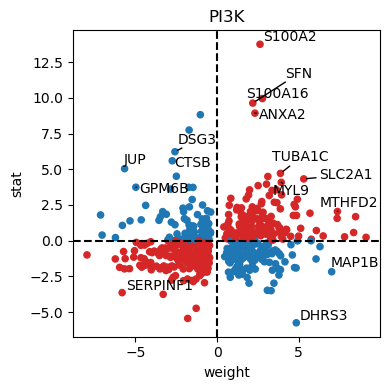

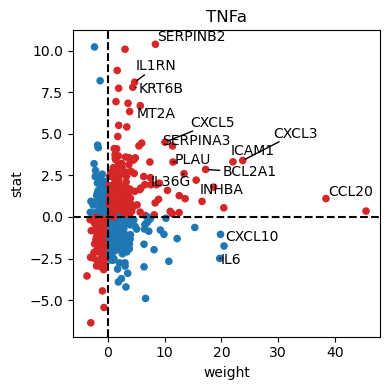

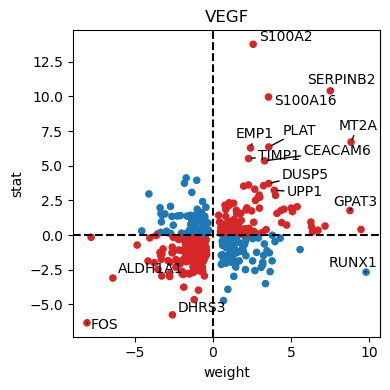

In [50]:
pw_list = pw_acts.columns.tolist()

for pw in pw_list:
    dc.pl.source_targets(
        data=results_df, 
        x="weight", 
        y="stat", 
        net=progeny, 
        name=pw, 
        top=15, 
        figsize=(4, 4)
    )

(+) EGFR leading edge: ['KRT6A' 'S100A2' 'S100A14' 'SPRR2A' 'S100A9' 'S100A16' 'SFN' 'S100A10'
 'KRT6B' 'TM4SF1']
(-) EGFR leading edge: ['DHRS3' 'CYP4B1' 'BCAM' 'DLL1' 'SCPEP1' 'LRIG1' 'COL4A5' 'ACSS3' 'ALDH2'
 'SELENOP']
(+) MAPK leading edge: ['KRT6A' 'S100A2' 'S100A14' 'SPRR2A' 'SERPINB2' 'S100A16' 'SFN' 'TM4SF1'
 'ANXA1' 'LAMC2']
(-) MAPK leading edge: ['KRT15' 'DHRS3' 'CYP4B1' 'BCAM' 'RARRES1' 'DLL1' 'SCPEP1' 'COL4A5'
 'HLA-DPA1' 'EPAS1']
(+) NFkB leading edge: ['SERPINB2' 'S100A9' 'CSTB' 'IL1RN' 'KRT6B' 'SERPINB1' 'ANXA1' 'LAMC2'
 'MT2A' 'PLAT']
(-) NFkB leading edge: ['KRT15' 'ID1' 'PTEN' 'AASS' 'FUCA1' 'WWTR1' 'SESN3' 'PTCH1' 'SLC40A1'
 'JAG2']
(+) PI3K leading edge: ['S100A2' 'S100A16' 'SFN' 'ANXA2' 'TUBA1C' 'PXDN' 'SLC2A1' 'MYL9' 'ODC1'
 'EIF4EBP1']
(-) PI3K leading edge: ['BCAM' 'SCPEP1' 'SELENOP' 'SERPINF1' 'WWTR1' 'BAIAP3' 'ALDH3B1' 'RFX3'
 'ABCA5' 'MLF1']
(+) TNFa leading edge: ['SERPINB2' 'S100A9' 'CSTB' 'IL1RN' 'KRT6B' 'SERPINB1' 'ANXA1' 'LAMC2'
 'MT2A' 'PLAT']
(-) TNF

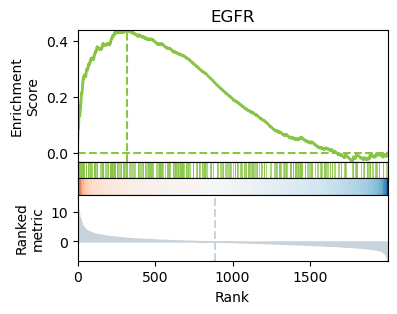

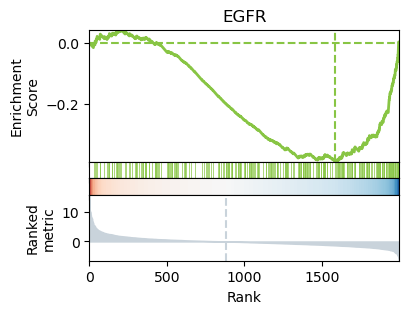

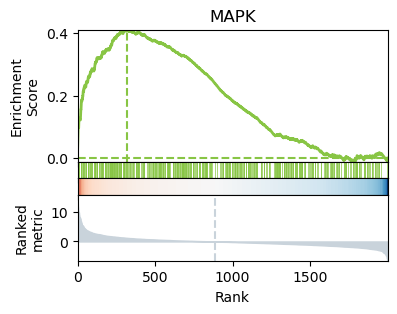

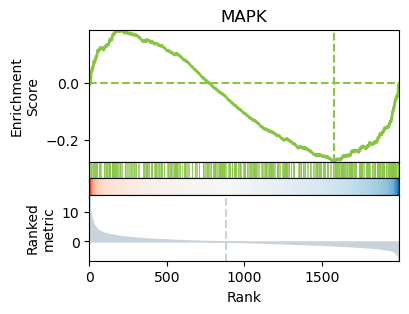

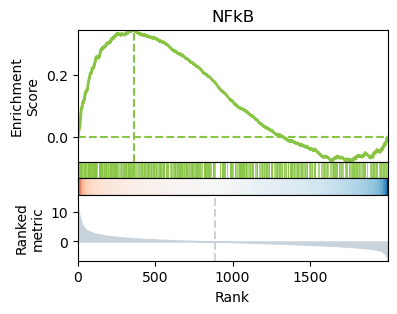

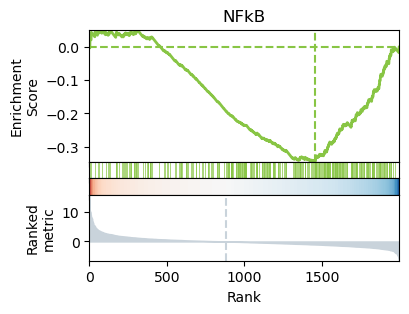

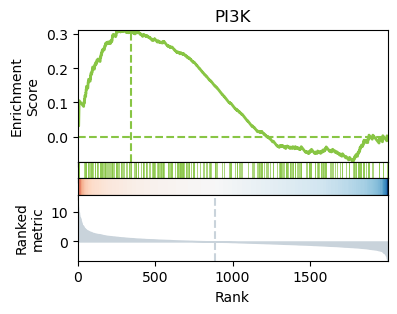

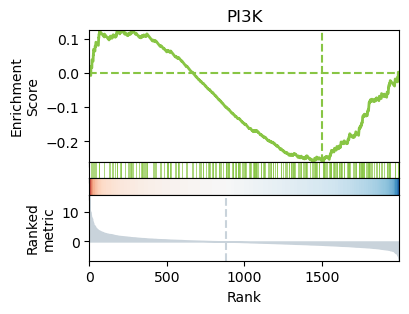

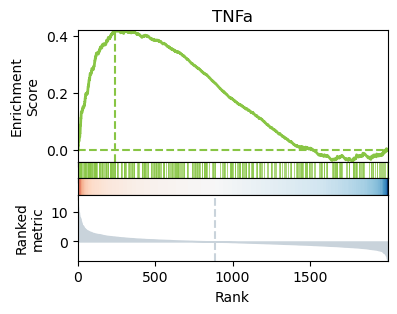

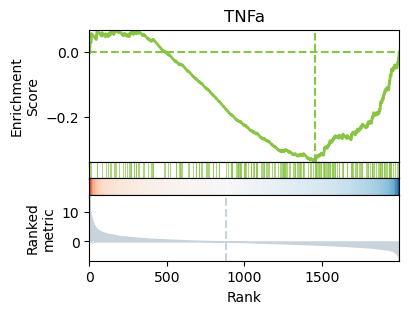

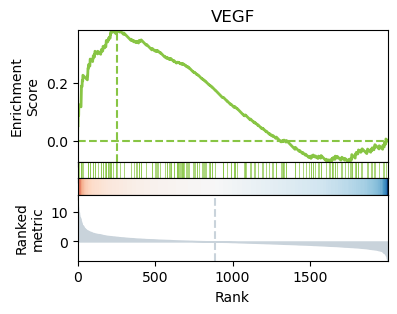

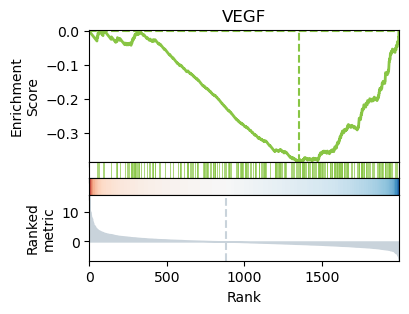

In [54]:
for pw in pw_list:

    _, pos_le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=progeny[progeny["weight"] > 0],
    name=pw,
    )
    print(f"(+) {pw} leading edge:", pos_le[:10])
    
    _, neg_le = dc.pl.leading_edge(
        results_df,
        stat="stat",
        net=progeny[progeny["weight"] < 0],
        name=pw,
    )
    print(f"(-) {pw} leading edge:", neg_le[:10])

## Hallmark

In [55]:
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


In [56]:
# Run
hm_acts, hm_padj = dc.mt.ulm(data=data, net=hallmark)

# Filter by sign padj
msk = (hm_padj.T < 0.05).iloc[:, 0]
hm_acts = hm_acts.loc[:, msk]

hm_acts

,APICAL_JUNCTION,APOPTOSIS,COAGULATION,COMPLEMENT,E2F_TARGETS,EPITHELIAL_MESENCHYMAL_TRANSITION,ESTROGEN_RESPONSE_LATE,G2M_CHECKPOINT
disease.vs.normal,3.817585,3.065252,3.566627,2.79181,3.406516,3.152528,4.661174,3.255379


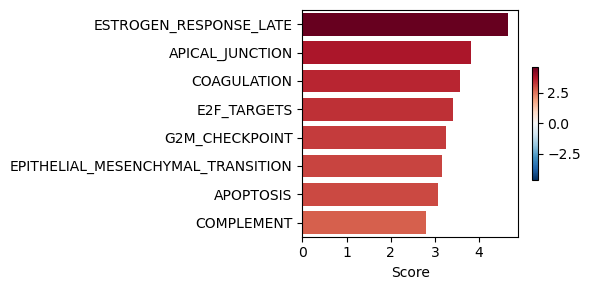

In [57]:
dc.pl.barplot(data=hm_acts, name="disease.vs.normal", figsize=(6, 3))

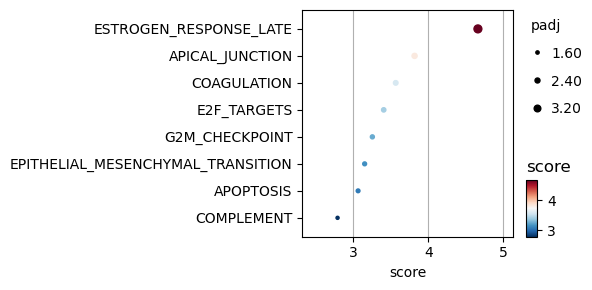

In [58]:
# Tranform to df
df = hm_acts.melt(value_name="score").merge(
    hm_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: np.log10(x["pvalue"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="padj", c="score", scale=0.25, figsize=(6, 3))

APICAL_JUNCTION leading edge: ['LAMC2' 'CLDN4' 'JUP' 'DSC3' 'MYL9' 'CLDN7' 'CDH3' 'CDH1' 'ICAM1' 'CD276']
APOPTOSIS leading edge: ['ANXA1' 'PLAT' 'EMP1' 'HSPB1' 'TIMP1' 'CDKN1A' 'TSPO' 'BGN' 'GADD45A'
 'CAV1']
COAGULATION leading edge: ['SERPINB2' 'ANXA1' 'PLAT' 'CTSB' 'TIMP1' 'CFB' 'PLAU' 'FN1' 'MMP14'
 'SERPINE1']
COMPLEMENT leading edge: ['SERPINB2' 'S100A9' 'PLAT' 'CTSB' 'TIMP1' 'KYNU' 'DUSP5' 'PLAUR' 'CFB'
 'FN1']
E2F_TARGETS leading edge: ['HMGA1' 'CDKN1A' 'H2AZ1' 'STMN1' 'UBE2S' 'RFC2' 'MTHFD2' 'MKI67' 'RRM2'
 'KIF2C']
EPITHELIAL_MESENCHYMAL_TRANSITION leading edge: ['LAMC2' 'TIMP1' 'MYL9' 'FLNA' 'PLAUR' 'TNC' 'BGN' 'LOX' 'FN1' 'LOXL2']
ESTROGEN_RESPONSE_LATE leading edge: ['S100A9' 'SFN' 'LAMC2' 'FABP5' 'ASS1' 'SERPINA3' 'KRT13' 'CDH1' 'FLNB'
 'KLF4']
G2M_CHECKPOINT leading edge: ['MT2A' 'HMGA1' 'H2AZ1' 'ODC1' 'STMN1' 'UBE2S' 'E2F4' 'MKI67' 'SLC7A5'
 'RASAL2']


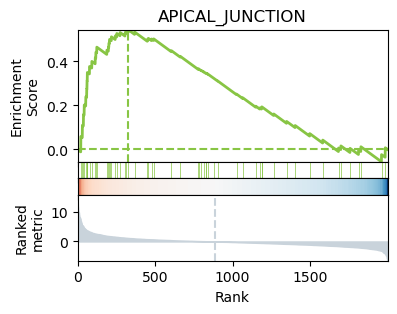

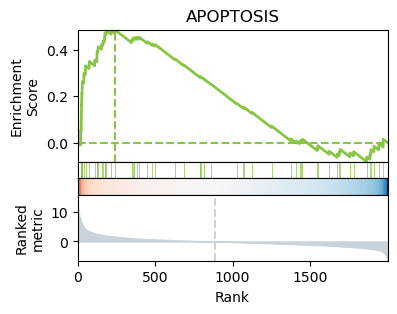

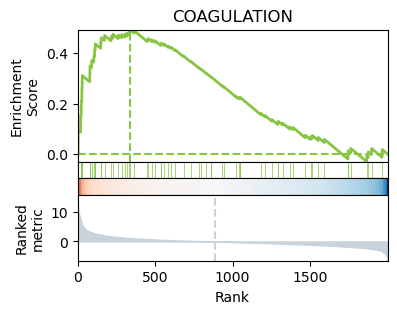

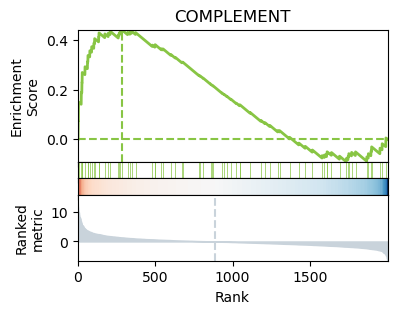

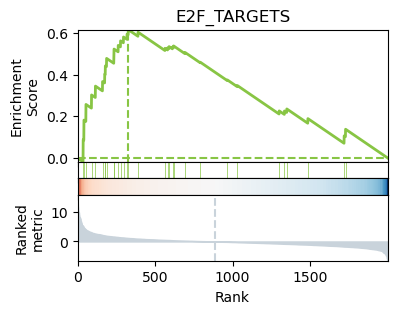

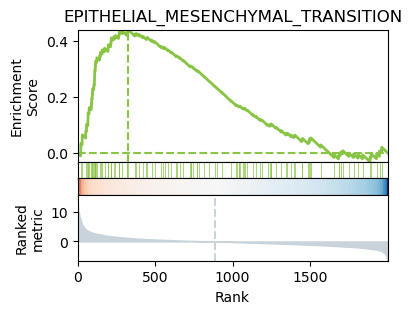

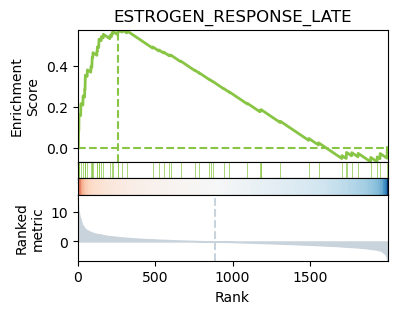

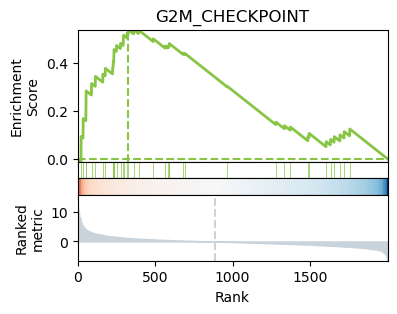

In [62]:
hmpw_list = hm_acts.columns.tolist()

for hmpw in hmpw_list:

    _, le = dc.pl.leading_edge(
        results_df,
        stat="stat",
        net=hallmark,
        name=hmpw,
    )
    print(f"{hmpw} leading edge:", le[:10])